# Módulo 6 — MA sobre precios: por qué la escalera se queda en MA(2)
Mismo dataset y preprocesado que `02_ma_retornos_ftse.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats.distributions import chi2
import warnings
warnings.filterwarnings("ignore")

def LLR_test(mod_1, mod_2, DF=1):
    L1 = mod_1.llf
    L2 = mod_2.llf
    LR = (2*(L2-L1))
    p = chi2.sf(LR, DF).round(3)
    return p

In [2]:
raw_csv_data = pd.read_csv("Index2018.csv")
df_comp = raw_csv_data.copy()
df_comp.date = pd.to_datetime(df_comp.date, dayfirst=True)
df_comp.set_index("date", inplace=True)
df_comp = df_comp.asfreq('B')
df_comp = df_comp.ffill()

df_comp['market_value'] = df_comp.ftse
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size = int(len(df_comp)*0.8)
df, df_test = df_comp.iloc[:size], df_comp.iloc[size:]

## ACF de los precios en nivel

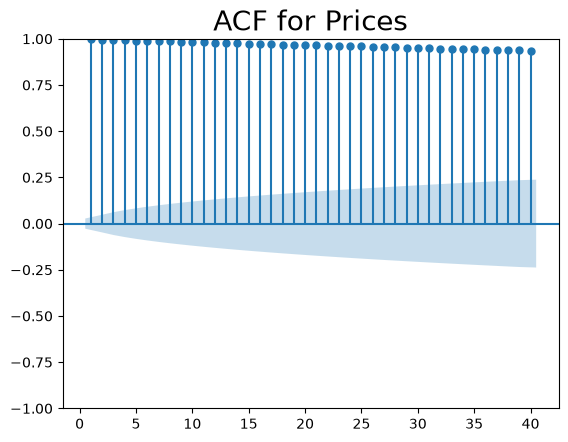

In [3]:
sgt.plot_acf(df.market_value, zero=False, lags=40)
plt.title("ACF for Prices", size=20)
plt.show()

## MA(1) sobre precios

In [4]:
model_ma_1 = ARIMA(df.market_value, order=(0, 0, 1))
results_ma_1 = model_ma_1.fit()
results_ma_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           market_value   No. Observations:                 5021
Model:                 ARIMA(0, 0, 1)   Log Likelihood              -38629.000
Date:                Wed, 16 Sep 2026   AIC                          77264.000
Time:                        18:55:30   BIC                          77283.564
Sample:                    01-07-1994   HQIC                         77270.856
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6317     15.834    321.441      0.000    5058.598    5120.665
ma.L1          0.9573      0.004    231.410      0.000       0.949       0.965
sigma2      2.817e+05   8160.528     34.519      0.000    2.66e+05    2.98e+05
===================================================================================
Ljung-Box (L1) (Q):                4221.11   Jarque-Bera (JB):               291.39
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.44   Skew:                            -0.39
Prob(H) (two-sided):                  0.00   Kurtosis:                         2.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## MA(2) sobre precios

In [5]:
model_ma_2 = ARIMA(df.market_value, order=(0, 0, 2))
results_ma_2 = model_ma_2.fit()
results_ma_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           market_value   No. Observations:                 5021
Model:                 ARIMA(0, 0, 2)   Log Likelihood              -36017.000
Date:                Wed, 16 Sep 2026   AIC                          72041.999
Time:                        18:55:31   BIC                          72068.085
Sample:                    01-07-1994   HQIC                         72051.140
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6308     16.259    313.043      0.000    5057.765    5121.497
ma.L1          1.6060      0.007    229.010      0.000       1.592       1.620
ma.L2          0.8703      0.007    123.020      0.000       0.856       0.884
sigma2      9.949e+04   2687.121     37.026      0.000    9.42e+04    1.05e+05
===================================================================================
Ljung-Box (L1) (Q):                2747.96   Jarque-Bera (JB):               188.85
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.52   Skew:                            -0.25
Prob(H) (two-sided):                  0.00   Kurtosis:                         2.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [6]:
print("LLR MA(1) vs MA(2) en precios:", LLR_test(results_ma_1, results_ma_2))
print("MA(1) retornos AIC (ver notebook 02): 15865.190")
print("MA(1) precios AIC:", results_ma_1.aic)

LLR MA(1) vs MA(2) en precios: 0.0
MA(1) retornos AIC (ver notebook 02): 15865.190
MA(1) precios AIC: 77264.00021592065
